# Predictive Maintenance: Machine Failure Prediction

**Objective**
To build a Machine Learning model that predicts equipment failure from sensor data (Temperature, Torque, and Wear), transforming reactive repairs into predictive maintenance.

**Key Challenges**
1. Imbalanced Data: Failures represent only 3% of the dataset, making "Accuracy" a misleading metric.
2. Goal: Maximize Recall (catching every failure) while maintaining high Precision (avoiding false alarms).

**Approach**
Train a Logistic Regression model as a simple benchmark and then move training to a non linear Random Forest classifier and Gradient Boosting Classifier to capture complex patterns.

**Evaluation**
 Compare performance using Confusion Matrices and Classification Reports.

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mlt
import matplotlib.pyplot as plt

In [17]:
data = pd.read_csv("../data/raw_data.csv")

# getting the structure of data 
print("Data Structure: \n")
data.info()

# getting the summary of the data for a high level insight
print("\n Summary of Data: \n")
print(data.describe())

#showing counts of machine failure
print("\n" , data["Machine failure"].value_counts())

Data Structure: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: fl

As the results of the above cell show this dataset consist of 10000 entries and 14 features consisting of 
=> 2 IDs (UDI and Prodcut ID)
=> a hardware quality "Type" feature with the letter (L, M, or H) from the Product ID , 
=> 5 sensor features columns ("Air Temperature", "Process Temperature", "Rotational speed", "Torque", "Tool wear") used to predict and    identify the cause of failure in machine performance,
=> "Machine Failure" feature with possible values 1 (failure) or 0 (no failure).
=>  5 Failure labels ("TWF", "HDF", "PWF", "OSF", "RNF") the ground truth labels for machine failure, if anyone of these is true then "Machine Failure" is set to 1.

Also it is quite clear for the observations above that the machine failure rate is much less than the no failure rate which means the data is imbalanced so while working on the models we will be considering the Precision and Recall and F1 score model metrics too along with Accuracy so that the model does not provide misleading results based on the majority of NO machine failures in the data.

In [18]:
#removing the IDs columns before training to avoid overfitting 
cleaned_data = data.drop(columns=["UDI","Product ID"]) 

# dropping the Failure labels so the model cannot cheat
cleaned_data.drop(columns={"TWF", "PWF", "HDF", "OSF", "RNF"}, inplace=True)

# renaming columns consisting of spaces and special character
cleaned_data = cleaned_data.rename(columns={"Air temperature [K]": "Air temperature", "Process temperature [K]": "Process temperature", "Rotational speed [rpm]": "Rotational speed", "Torque [Nm]" : "Torque", "Tool wear [min]": "Tool wear"})

# checking duplicates if any in the original dataset
print("Duplicate values:" , cleaned_data.duplicated().sum())

# checking null values
print("Null values:\n", cleaned_data.isnull().sum())

# map Type feaures to 0 ,1 ,2 as maching algorithm will understand only numbers
type_dictionary = { "L" : 0 , "M" : 1 , "H" : 2 }
cleaned_data["Type"] = cleaned_data["Type"].replace(type_dictionary)

cleaned_data.to_csv("../data/cleaned_data.csv", index=False)
print(cleaned_data.info())

Duplicate values: 0
Null values:
 Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
Machine failure        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  int64  
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Torque               10000 non-null  float64
 5   Tool wear            10000 non-null  int64  
 6   Machine failure      10000 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 547.0 KB
None


C:\Users\urooj\AppData\Local\Temp\ipykernel_27516\4025877825.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned_data["Type"] = cleaned_data["Type"].replace(type_dictionary)


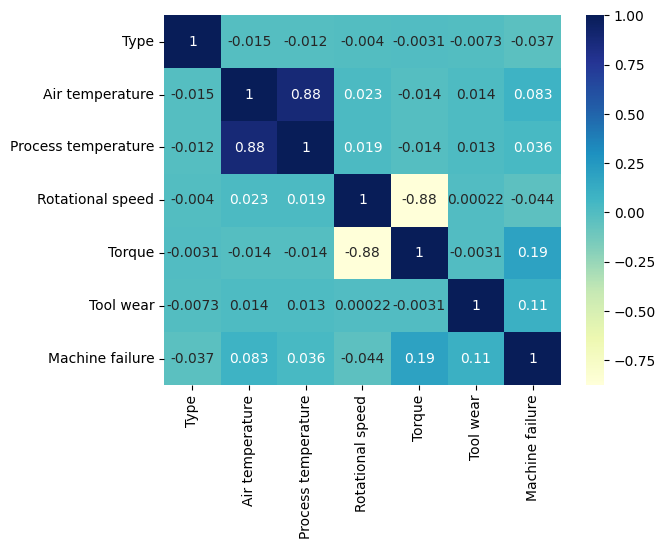

In [19]:
corr_data = cleaned_data.corr(numeric_only=True)
sns.heatmap(corr_data, cmap="YlGnBu", annot=True)
plt.show()

Based on the above heatmap it can be said that:

1. "Process Temperature" and "Air Temperature" have high correlation indicating that the machine internal heat is firectly proportinal to the overall facory heat which might means that we donot want both of these since both are telling the same story and can lead to data redundancy.

2. "Torque" and "Rotational speed" are highly negatively correlated to each other indicating that you cannot have both high speed and high torque otherwise machine would collapse

3. "Torque" and "Tool wear" are significantly more concernable as they have high positive correlation witt machine failures. "Air temperature" is also to look into but less significant.


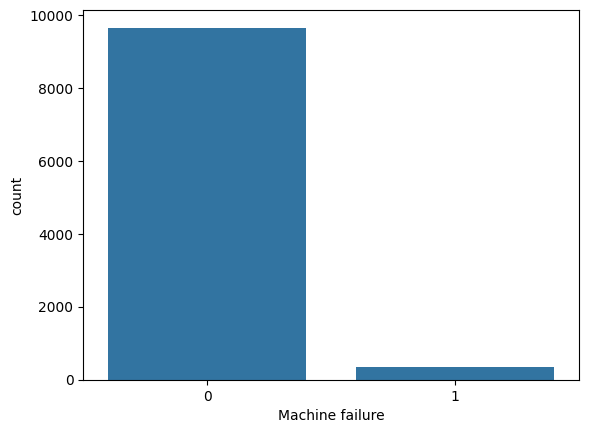

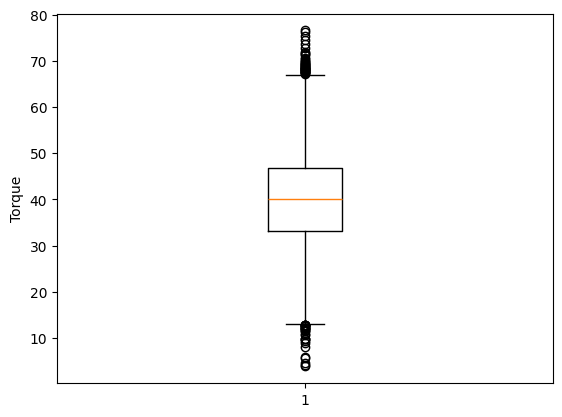

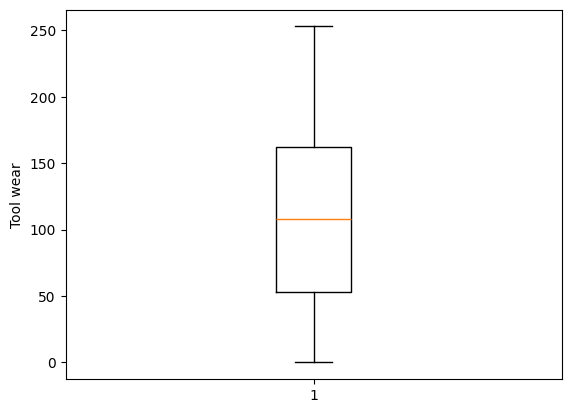

In [20]:
sns.countplot(x = "Machine failure", data = cleaned_data)
plt.show()


cols = ["Torque", "Tool wear"]
for feature in cols:
    plt.boxplot(cleaned_data[feature])
    plt.ylabel(feature)
    plt.show()